# p-valor em um experimento com moeda

Este notebook acompanha a Secao 1 com foco em uma unica pergunta: como o p-valor muda quando observamos um resultado mais ou menos extremo sob $H_0$?

Vamos usar o experimento das notas: 20 lancamentos de moeda, com 16 caras observadas.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom

n = 20
p0 = 0.5
k_obs = 16
rng = np.random.default_rng(1625)

## 1. Calculando o p-valor para diferentes hipoteses alternativas

O mesmo dado observado gera p-valores diferentes dependendo da pergunta estatistica:

- $H_a: p > 0.5$  -> cauda a direita;
- $H_a: p < 0.5$  -> cauda a esquerda;
- $H_a: p 
e 0.5$ -> teste bicaudal.

In [2]:
p_maior = binom.sf(k_obs - 1, n, p0)
p_menor = binom.cdf(k_obs, n, p0)
prob_extremos = binom.pmf(np.arange(n + 1), n, p0)
p_bicaudal = prob_extremos[prob_extremos <= binom.pmf(k_obs, n, p0)].sum()

print(f"P(X >= {k_obs})  = {p_maior:.4f}   [alternativa: mais caras]")
print(f"P(X <= {k_obs})  = {p_menor:.4f}   [alternativa: menos caras]")
print(f"p-valor bicaudal = {p_bicaudal:.4f}")

P(X >= 16)  = 0.0059   [alternativa: mais caras]
P(X <= 16)  = 0.9987   [alternativa: menos caras]
p-valor bicaudal = 0.0118


## 2. Visualizando a regiao do p-valor

No teste unilateral a direita, o p-valor e a probabilidade de observar $k_{obs}$ ou mais caras sob a hipotese de moeda justa.

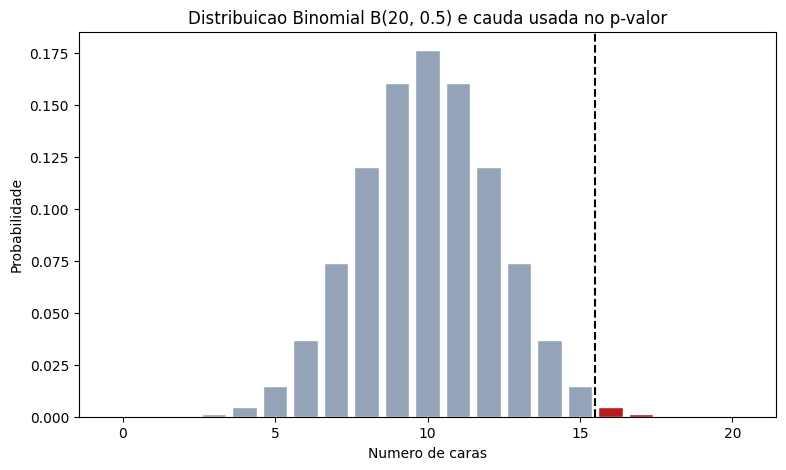

In [3]:
x = np.arange(n + 1)
pmf = binom.pmf(x, n, p0)
cores = np.where(x >= k_obs, '#b91c1c', '#94a3b8')

plt.figure(figsize=(9, 5))
plt.bar(x, pmf, color=cores, edgecolor='white')
plt.axvline(k_obs - 0.5, color='black', linestyle='--', linewidth=1.5)
plt.title('Distribuicao Binomial B(20, 0.5) e cauda usada no p-valor')
plt.xlabel('Numero de caras')
plt.ylabel('Probabilidade')
plt.show()

## 3. Conferindo o p-valor por simulacao

Agora repetimos o experimento muitas vezes assumindo que $H_0$ e verdadeira. A fracao de experimentos com 16 ou mais caras deve ficar proxima do p-valor exato.

In [4]:
n_sim = 200_000
caras_simuladas = rng.binomial(n=n, p=p0, size=n_sim)
p_simulado = np.mean(caras_simuladas >= k_obs)

print(f"p-valor exato      = {p_maior:.4f}")
print(f"p-valor por simulacao = {p_simulado:.4f}")

p-valor exato      = 0.0059
p-valor por simulacao = 0.0057


## 4. Extremidade observada versus p-valor

Para ver a relacao entre "resultado extremo" e evidencia contra $H_0$, calculamos o p-valor para cada numero possivel de caras, mantendo fixa a alternativa $H_a: p > 0.5$.

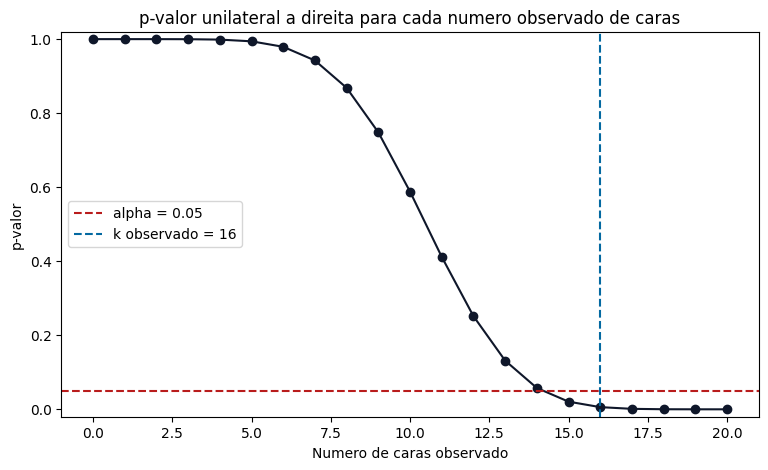

In [5]:
k_vals = np.arange(0, n + 1)
p_vals = binom.sf(k_vals - 1, n, p0)

plt.figure(figsize=(9, 5))
plt.plot(k_vals, p_vals, marker='o', color='#0f172a')
plt.axhline(0.05, color='#b91c1c', linestyle='--', label='alpha = 0.05')
plt.axvline(k_obs, color='#0369a1', linestyle='--', label=f'k observado = {k_obs}')
plt.title('p-valor unilateral a direita para cada numero observado de caras')
plt.xlabel('Numero de caras observado')
plt.ylabel('p-valor')
plt.ylim(-0.02, 1.02)
plt.legend()
plt.show()

## 5. Fechamento

Este notebook serve para testar, em codigo, a definicao das notas:

- o p-valor e calculado assumindo $H_0$ verdadeira;
- a direcao da hipotese alternativa define qual cauda entra no calculo;
- quanto mais extremo o resultado observado, menor tende a ser o p-valor.